# IDS GCN-LSTM (Minimal Notebook)
Single training pipeline only. Extra trainings, confusion matrix, ROC, and k-fold removed.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Reshape

In [2]:
# Load + preprocess (memory-safe minimal)
dataset_columns = pd.read_csv('./NUSW-NB15_features.csv', encoding='ISO-8859-1')
feature_names = dataset_columns['Name'].tolist()

# Keep notebook light: limit rows per CSV file (increase later if RAM allows)
MAX_ROWS_PER_FILE = 80000  # 4 files => max ~320k rows total
parts = []
for i in range(1, 5):
    df = pd.read_csv(
        f'./UNSW-NB15_{i}.csv',
        header=None,
        names=feature_names,
        nrows=MAX_ROWS_PER_FILE,
        low_memory=False
    )
    parts.append(df)

# IMPORTANT: ignore_index=True avoids expensive reset_index copy
combined_data = pd.concat(parts, ignore_index=True)
del parts

combined_data['attack_cat'] = combined_data['attack_cat'].fillna('normal').apply(lambda x: x.strip().lower())
combined_data['attack_cat'] = combined_data['attack_cat'].replace('backdoors', 'backdoor', regex=True).apply(lambda x: x.strip().lower())
combined_data['ct_flw_http_mthd'] = combined_data['ct_flw_http_mthd'].fillna(0)
combined_data['is_ftp_login'] = combined_data['is_ftp_login'].fillna(0)
combined_data['is_ftp_login'] = np.where(combined_data['is_ftp_login'] > 1, 1, combined_data['is_ftp_login'])
combined_data['service'] = combined_data['service'].apply(lambda x: 'None' if x == '-' else x)
combined_data['ct_ftp_cmd'] = combined_data['ct_ftp_cmd'].replace(to_replace=' ', value=0).astype(int)

combined_data.drop(columns=['srcip', 'sport', 'dstip', 'dsport', 'Label'], inplace=True)

train, test = train_test_split(combined_data, test_size=0.2, random_state=16)
train, val = train_test_split(train, test_size=0.2, random_state=16)

x_train, y_train = train.drop(columns=['attack_cat']), train[['attack_cat']]
x_test, y_test = test.drop(columns=['attack_cat']), test[['attack_cat']]
x_val, y_val = val.drop(columns=['attack_cat']), val[['attack_cat']]

cat_col = ['proto', 'service', 'state']
num_col = list(set(x_train.columns) - set(cat_col))

scaler = StandardScaler().fit(x_train[num_col])
x_train[num_col] = scaler.transform(x_train[num_col])
x_test[num_col] = scaler.transform(x_test[num_col])
x_val[num_col] = scaler.transform(x_val[num_col])

# handle_unknown='ignore' prevents errors when test/val have unseen categories
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_col)],
    remainder='passthrough'
    )
x_train = np.array(ct.fit_transform(x_train), dtype=np.float32)
x_test = np.array(ct.transform(x_test), dtype=np.float32)
x_val = np.array(ct.transform(x_val), dtype=np.float32)

# Also guard target encoding for rare labels absent in train split
attacks = y_train['attack_cat'].unique()
ct1 = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(categories=[attacks], sparse_output=False, handle_unknown='ignore'), ['attack_cat'])],
    remainder='passthrough'
    )
y_train = np.array(ct1.fit_transform(y_train), dtype=np.float32)
y_test = np.array(ct1.transform(y_test), dtype=np.float32)
y_val = np.array(ct1.transform(y_val), dtype=np.float32)

print('Rows loaded:', len(combined_data))
print('Shapes:', x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape)

Rows loaded: 320000
Shapes: (204800, 201) (204800, 10) (51200, 201) (51200, 10) (64000, 201) (64000, 10)


In [3]:
# Single model
n_features = x_train.shape[1]

model = Sequential([
    Reshape((n_features, 1), input_shape=(n_features,)),
    Reshape((1, n_features)),
    LSTM(32, return_sequences=True),
    BatchNormalization(),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    LSTM(64),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ashis\.conda\envs\tf9\lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 201)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 32)          │        29,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,434 (419.66 KB)

 Trainable params: 107,114 (418.41 KB)

 Non-trainable params: 320 (1.25 KB)

In [4]:
# Single training run
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc*100:.2f}%')

Epoch 1/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9276 - loss: 0.2438 - val_accuracy: 0.9709 - val_loss: 0.0773
Epoch 2/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9697 - loss: 0.0814 - val_accuracy: 0.9716 - val_loss: 0.0738
Epoch 3/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9713 - loss: 0.0764 - val_accuracy: 0.9710 - val_loss: 0.0739
Epoch 4/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9714 - loss: 0.0750 - val_accuracy: 0.9724 - val_loss: 0.0699
Epoch 5/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9721 - loss: 0.0735 - val_accuracy: 0.9734 - val_loss: 0.0705
Epoch 6/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9719 - loss: 0.0738 - val_accuracy: 0.9732 - val_loss: 0.0689
Epoch 7/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9731 - loss: 0.0706 - val_accuracy: 0.9734 - val_loss: 0.0678
Epoch 8/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9726 - loss: 0.0710 - val_accuracy: 0.

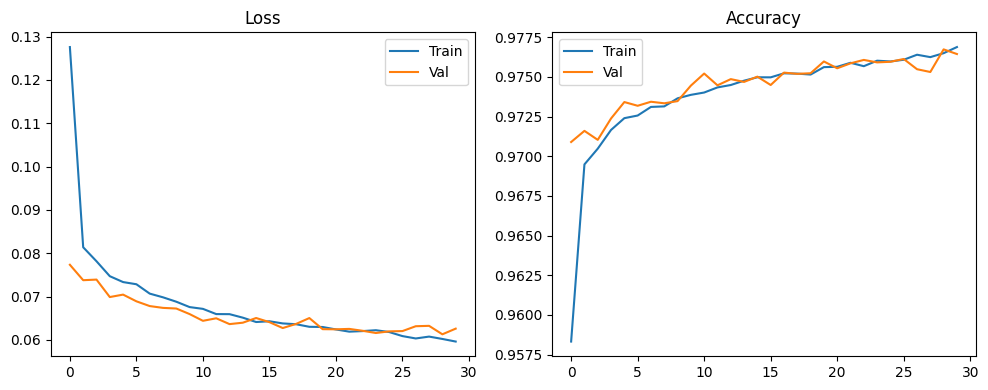

In [5]:
# Minimal plots
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()